In [1]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.decomposition import PCA
from scipy.stats import randint
from sklearn.metrics import accuracy_score

In [2]:
def load_images(folder):
    data = []
    labels = []
    for label_name in ['cat', 'dog']:
        label = 0 if label_name == 'cat' else 1
        folder_path = os.path.join(folder, label_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.flatten() / 255.0  
            data.append(img)
            labels.append(label)
    return np.array(data), np.array(labels)

In [3]:
train_dir = r"C:\Users\thuuy\_python\ml\data_folder\train"
test_dir = r"C:\Users\thuuy\_python\ml\data_folder\test"
val_dir = r"C:\Users\thuuy\_python\ml\data_folder\val"


In [4]:
X_train, y_train = load_images(train_dir)
X_val, y_val     = load_images(val_dir)
X_test, y_test   = load_images(test_dir)

In [5]:
print("Train set:", X_train.shape, y_train.shape)
print("Val set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (20000, 12288) (20000,)
Val set: (2500, 12288) (2500,)
Test set: (2500, 12288) (2500,)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      
X_val_scaled = scaler.transform(X_val)             
X_test_scaled = scaler.transform(X_test)            

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)     
X_val_pca = pca.transform(X_val_scaled)             
X_test_pca = pca.transform(X_test_scaled)           

In [7]:
X_search, _, y_search, _ = train_test_split(X_train_pca, y_train, train_size=0.15, stratify=y_train, random_state=42)

svm = SVC(kernel='rbf', gamma='scale', random_state=42)

param_dist = {
    'C': randint(1, 100)
}

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [8]:
random_search.fit(X_search, y_search)

best_params = random_search.best_params_
print("Best params:", best_params)

svm_model = SVC(kernel='rbf', gamma='scale', C=best_params['C'], random_state=42)
svm_model.fit(X_train_pca, y_train)

y_val_pred = svm_model.predict(X_val_pca)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'C': 15}
Validation accuracy: 0.658


In [9]:
y_test_pred = svm_model.predict(X_test_pca)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Test accuracy: 0.6608



Classification Report on Test Set:

              precision    recall  f1-score   support

         Cat       0.67      0.65      0.66      1267
         Dog       0.65      0.67      0.66      1233

    accuracy                           0.66      2500
   macro avg       0.66      0.66      0.66      2500
weighted avg       0.66      0.66      0.66      2500

Confusion Matrix:
 [[828 439]
 [409 824]]
Confusion matrix saved to svm_confusion_matrix.png


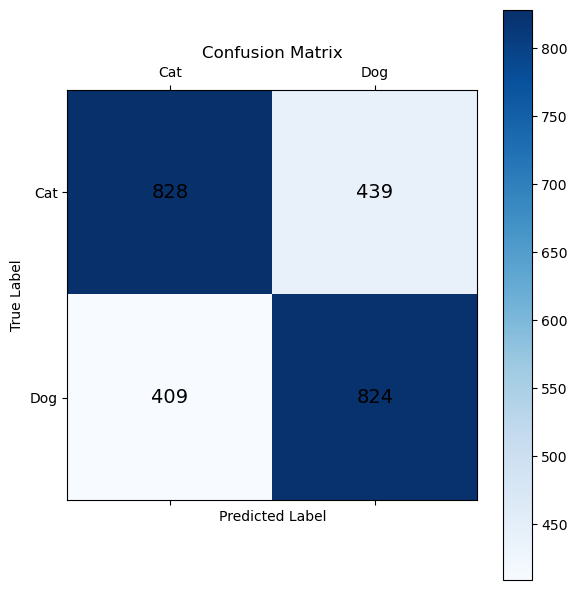

In [12]:
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, target_names=['Cat', 'Dog']))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

def plot_confusion_matrix(cm, class_names, save_path='svm_confusion_matrix.png'):
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    plt.colorbar(cax)
    
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14)
    
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"Confusion matrix saved to {save_path}")
    
    plt.show()

plot_confusion_matrix(cm, ['Cat', 'Dog'])

